**Tools**



Tools extend what agents can do—letting them fetch real-time data, execute code, query external databases, and take actions in the world.

In [2]:
from langchain_groq import ChatGroq
import os 
from dotenv import load_dotenv
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv("MODEL_NAME")
MULTI_MODEL = os.getenv("MULTI_MODEL_NAME")


In [5]:
llm = ChatGroq(
    model=GROQ_MODEL,
    api_key=GROQ_API_KEY,
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2
)

print("LLM loaded successfully 1✅")
message = [
    {"role": "system", "content": "You are a helpful assistant."},
]
ai_msg = llm.invoke(message)
print(ai_msg.content)

LLM loaded successfully 1✅
Hello! How can I assist you today?


In [6]:
from langchain_core.messages import HumanMessage
multi_model = ChatGroq(
    model=MULTI_MODEL,
    groq_api_key=GROQ_API_KEY,
)

message = HumanMessage(
    content=[
        {"type":"text", "text":"What do you see in this image?"},
        {
            "type":"image_url",
            "image_url":{"url":"https://i.imgur.com/7ntlWNJ.png"}
        }
    ]
)

response = multi_model.invoke([message])

print(response.content)

The image depicts a political cartoon titled "Bagley Cartoon: The Unwokening" and features a group of people holding signs with messages such as "Help the Helpless," "Feed the Hungry," and "Love Your Neighbor." These signs suggest that the individuals are advocating for social and humanitarian causes.

However, two men in suits are shown fleeing from the scene, with one of them saying, "All this woke stuff is against my deeply held personal and religious beliefs." This statement implies that the men are rejecting or resisting the progressive or liberal values represented by the signs.

The cartoon appears to be commenting on the current political climate and the divide between conservative and liberal ideologies. The use of the term "woke" is a reference to the concept of being socially aware and informed about issues such as social justice and equality.

Overall, the image suggests that some individuals may claim to have deeply held personal and religious beliefs that conflict with pr

In [7]:
from langchain.tools import tool

@tool
def search_database(query: str, limit: int = 10) -> str:
    """Search the customer database for records matching the query.

    Args:
        query: Search terms to look for
        limit: Maximum number of results to return
    """
    return f"Found {limit} results for '{query}'"

In [8]:
from langgraph.types import Command
from langchain.tools import tool

@tool
def set_user_name(new_name: str) -> Command:
    """Set the user's name in the conversation state."""
    return Command(update={"user_name": new_name})


**Context**

Context provides immutable configuration data that is passed at invocation time. Use it for user IDs, session details, or application-specific settings that shouldn’t change during a conversation.


Access context through runtime.context:

In [9]:
from dataclasses import dataclass
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime


USER_DATABASE = {
    "user123": {
        "name": "Alice Johnson",
        "account_type": "Premium",
        "balance": 5000,
        "email": "alice@example.com"
    },
    "user456": {
        "name": "Bob Smith",
        "account_type": "Standard",
        "balance": 1200,
        "email": "bob@example.com"
    }
}

@dataclass
class UserContext:
    user_id: str

@tool
def get_account_info(runtime: ToolRuntime[UserContext]) -> str:
    """Get the current user's account information."""
    user_id = runtime.context.user_id

    if user_id in USER_DATABASE:
        user = USER_DATABASE[user_id]
        return f"Account holder: {user['name']}\nType: {user['account_type']}\nBalance: ${user['balance']}"
    return "User not found"


agent = create_agent(
    model=llm,
    tools=[get_account_info],
    context_schema=UserContext,
    system_prompt="You are a financial assistant."
)

result = agent.invoke(
    {"messages": [{"role": "user", "content": "What's my current balance?"}]},
    context=UserContext(user_id="user123")
)

print(result)

{'messages': [HumanMessage(content="What's my current balance?", additional_kwargs={}, response_metadata={}, id='e212c605-9b44-421c-a40c-6f160ff34291'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks "What\'s my current balance?" As a financial assistant, we need to retrieve account info. Use get_account_info function.', 'tool_calls': [{'id': 'fc_b39569e9-bcff-414b-828d-68dc24ffb01c', 'function': {'arguments': '{}', 'name': 'get_account_info'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 131, 'total_tokens': 179, 'completion_time': 0.099992118, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.005553089, 'prompt_tokens_details': None, 'queue_time': 0.045221931, 'total_time': 0.105545207}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--0

***Long-term memory (Store)***

The BaseStore provides persistent storage that survives across conversations. Unlike state (short-term memory), data saved to the store remains available in future sessions.


Access the store through runtime.store. The store uses a namespace/key pattern to organize data:

In [15]:
from typing import Any
from langgraph.store.memory import InMemoryStore
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime


# Access memory
@tool
def get_user_info(user_id: str, runtime: ToolRuntime) -> str:
    """Look up user info."""
    store = runtime.store
    user_info = store.get(("users",), user_id)
    return str(user_info.value) if user_info else "Unknown user"

# Update memory
@tool
def save_user_info(user_id: str, user_info: dict[str, Any], runtime: ToolRuntime) -> str:
    """Save user info."""
    store = runtime.store
    store.put(("users",), user_id, user_info)
    return "Successfully saved user info."

store = InMemoryStore()

agent = create_agent(
    model =llm,
    tools=[get_user_info, save_user_info],
    store=store
)

# First session: save user info
response1 = agent.invoke({
    "messages": [{"role": "user", "content": "Save the following user: userid: abc123, name: Foo, age: 25, email: foo@langchain.dev"}]
})

print(response1)


{'messages': [HumanMessage(content='Save the following user: userid: abc123, name: Foo, age: 25, email: foo@langchain.dev', additional_kwargs={}, response_metadata={}, id='5827e640-e3c0-4b17-aaa9-674c1da9bd60'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call save_user_info with user_id "abc123" and user_info containing name, age, email. Use function.', 'tool_calls': [{'id': 'fc_7ce11d8d-69ab-4696-b25d-f9feff29ee8c', 'function': {'arguments': '{"user_id":"abc123","user_info":{"age":25,"email":"foo@langchain.dev","name":"Foo"}}', 'name': 'save_user_info'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 181, 'total_tokens': 272, 'completion_time': 0.200774009, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.007569317, 'prompt_tokens_details': None, 'queue_time': 0.046127843, 'total_time': 0.208343326}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'ser

In [16]:
print(response1['messages'][-1].content)

The user information has been saved successfully. Let me know if there’s anything else you’d like to do!


In [17]:
# Second session: get user info
response2 = agent.invoke({
    "messages": [{"role": "user", "content": "Get user info for user with id 'abc123'"}]
})

In [18]:
print(response2['messages'][-1].content)

Here’s the information for user **abc123**:

- **Name:** Foo  
- **Age:** 25  
- **Email:** foo@langchain.dev


**Simple tools and Memory Example** 

In [37]:
from typing import Any
from langchain.agents import create_agent
from langchain.tools import tool
from langgraph.store.memory import InMemoryStore
# Create the in-memory store
store = InMemoryStore()

In [38]:
@tool 
def save_user_info(user_id: str, user_info: dict[str, Any]) -> str:
    """save info to InMemoryStore"""
    namespace = ("users",)
    print("save user",namespace)
    store.put(namespace,user_id,user_info)
    return f"Successfully saved info for user {user_id}"

In [49]:
@tool
def get_user_info(user_id: str) -> str:
    namespace = ("users",)
    item = store.get(namespace, user_id)
    if item is None:
        return f"No info found for user {user_id}"
    return f"User {user_id} info: {item.value}"

ValueError: Function must have a docstring if description not provided.

In [45]:
agent = create_agent(
    model = llm,
    tools = [save_user_info, get_user_info],
    store = store
)

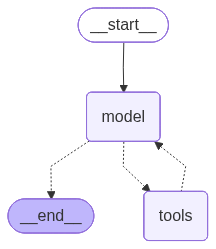

In [46]:
agent

In [52]:
# from typing import Any
# from langgraph.store.memory import InMemoryStore

# from langchain.tools import tool
# from langchain.agents import create_agent

# # Create memory store
# store = InMemoryStore()


# # --- Tools ---

# @tool(
#     name="save_user_info",
#     description="Save user information to the in-memory store"
# )
# def save_user_info(user_id: str, name: str, age: int, email: str) -> str:
#     namespace = ("users",)
#     user_info = {"name": name, "age": age, "email": email}
#     store.put(namespace, user_id, user_info)
#     return f"Saved info for user {user_id}"


# @tool(
#     name="get_user_info",
#     description="Get saved user information from the in-memory store"
# )
# def get_user_info(user_id: str) -> str:
#     namespace = ("users",)
#     item = store.get(namespace, user_id)
#     if item is None:
#         return f"No info found for user {user_id}"
#     return f"User {user_id} info: {item.value}"


# # --- Create and use agent ---

# agent = create_agent(
#     model=llm,           # your LLM object
#     tools=[save_user_info, get_user_info],
#     store=store
# )

# # Save example
# response1 = agent.invoke({
#     "messages": [
#         {
#             "role": "user",
#             "content": (
#                 "Save user info: user_id=abc123 name=Foo age=25 email=foo@langchain.dev"
#             )
#         }
#     ]
# })

# print(response1)

# # Get example
# response2 = agent.invoke({
#     "messages": [
#         {
#             "role": "user",
#             "content": "Get user info for user_id=abc123"
#         }
#     ]
# })

# print(response2)

In [54]:
from langchain.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, MessagesState, START, END

@tool
def search(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"

@tool
def calculator(expression: str) -> str:
    """Evaluate a math expression."""
    return str(eval(expression))

# Create the ToolNode with your tools
tool_node = ToolNode([search, calculator])

# Use in a graph
builder = StateGraph(MessagesState)
builder.add_node("tools", tool_node)
# ... add other nodes and edges

In [ ]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, MessagesState, START, END

builder = StateGraph(MessagesState)
builder.add_node("llm", call_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", tools_condition)  # Routes to "tools" or END
builder.add_edge("tools", "llm")

graph = builder.compile()

TypeError: 'ToolNode' object is not iterable